# Nairobi Healthcare Accessibility
**Research question:** How does healthcare accessibility differ between wealthy neighbourhoods (Karen, Westlands) and informal settlements (Kibera, Mathare) in Nairobi?

**Data required before running:**
- `data/raw/gis_osm_pois_free_1.shp` — from Geofabrik Kenya download
- `data/raw/ken_ppp_2020_UNadj.tif` — WorldPop Kenya 2020 population raster
- (Optional) `data/raw/gadm41_KEN.gpkg` — Kenya admin boundaries

In [32]:
import geopandas as gpd
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import h3
import rasterio
from rasterstats import zonal_stats
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import warnings
from shapely.geometry import box
warnings.filterwarnings('ignore')

# Paths
POI_PATH    = '../Data/raw/kenya-260510-free/gis_osm_pois_free_1.shp'
POP_RASTER  = '../Data/raw/ken_pop_2020_CN_100m_R2025A_v1.tif'
WALK_GRAPH  = '../Data/processed/nairobi_walk.graphml'

print('Libraries loaded OK')

Libraries loaded OK


## Step 1 — Load boundaries & filter OSM data

Nairobi CRS: epsg:4326


<Axes: >

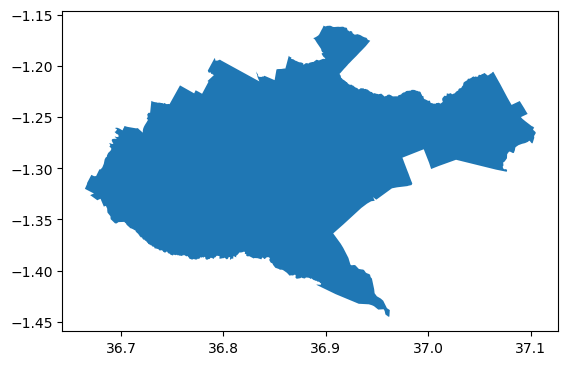

In [33]:
# Nairobi city boundary
nairobi = ox.geocode_to_gdf('Nairobi, Kenya')
nairobi_poly = nairobi.geometry.values[0]
print('Nairobi CRS:', nairobi.crs)
nairobi.plot()

In [34]:
# Four study areas
area_names = ['Karen', 'Westlands', 'Kibera', 'Mathare']
area_colors = {
    'Karen':     '#1f77b4',
    'Westlands': '#2ca02c',
    'Kibera':    '#d62728',
    'Mathare':   '#ff7f0e',
}

areas = {}
for name in area_names:
    if name == 'Kibera':
        # Kibera has no OSM polygon boundary — use known geographic extent
        areas[name] = gpd.GeoDataFrame(
            {'geometry': [box(36.760, -1.325, 36.815, -1.290)]},
            crs='EPSG:4326'
        )
        print('Kibera: OK (manual bbox)')
    else:
        try:
            areas[name] = ox.geocode_to_gdf(f'{name}, Nairobi, Kenya')
            print(f'{name}: OK')
        except Exception as e:
            print(f'{name}: FAILED — {e}')

Karen: OK
Westlands: OK
Kibera: OK (manual bbox)
Mathare: OK


In [35]:
# Load Kenya OSM POI and filter to health facilities
kenya_pois = gpd.read_file(POI_PATH)
print('POI columns:', kenya_pois.columns.tolist())
print('fclass values (top 30):'); print(kenya_pois['fclass'].value_counts().head(30))

POI columns: ['osm_id', 'code', 'fclass', 'name', 'geometry']
fclass values (top 30):
fclass
toilet              16055
school               7318
drinking_water       3425
water_well           3076
restaurant           2109
kindergarten         2073
marketplace          1829
hotel                1669
shelter              1196
bank                 1043
kiosk                1020
pharmacy              728
bar                   687
clinic                653
supermarket           631
convenience           490
guesthouse            457
tourist_info          455
community_centre      450
hospital              438
police                401
pub                   380
clothes               371
butcher               349
chemist               346
camp_site             336
cafe                  330
hairdresser           322
hostel                274
comms_tower           236
Name: count, dtype: int64


In [36]:
# Filter health facility types
health_types = ['hospital', 'clinic', 'pharmacy', 'doctors']
kenya_health = kenya_pois[kenya_pois['fclass'].isin(health_types)].copy()

# Ensure CRS matches
kenya_health = kenya_health.to_crs(nairobi.crs)

# Clip to Nairobi
nairobi_health = gpd.sjoin(kenya_health, nairobi[['geometry']], predicate='within').drop(columns='index_right')
print(f'Nairobi health facilities: {len(nairobi_health)}')
print(nairobi_health['fclass'].value_counts())

Nairobi health facilities: 980
fclass
pharmacy    475
clinic      351
hospital    146
doctors       8
Name: count, dtype: int64


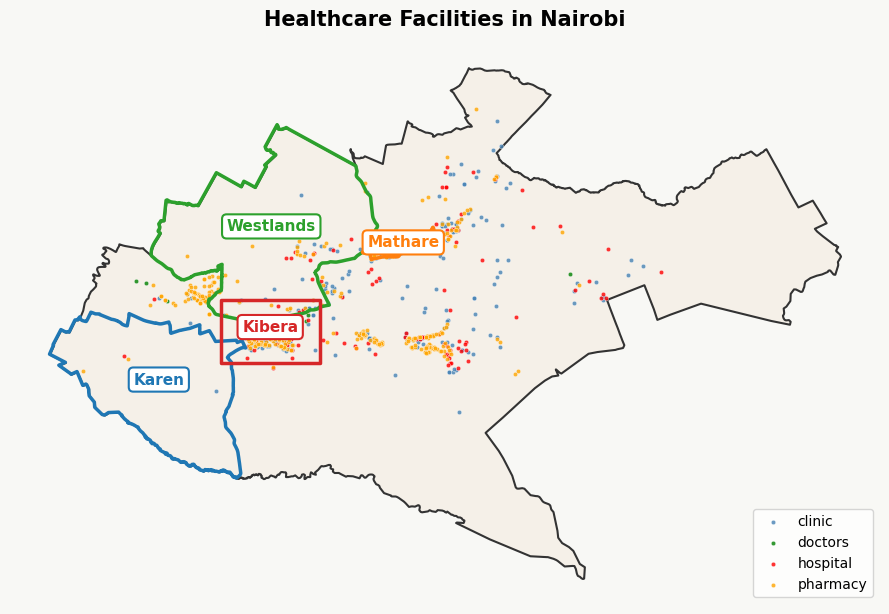

In [37]:
# Quick overview map
fig, ax = plt.subplots(figsize=(9, 9), facecolor='#f8f8f5')
nairobi.plot(ax=ax, color='#f5f0e8', edgecolor='#333', linewidth=1.5)

color_map = {'hospital': 'red', 'clinic': 'steelblue', 'pharmacy': 'orange', 'doctors': 'green'}
for fclass, grp in nairobi_health.groupby('fclass'):
    grp.plot(ax=ax, color=color_map.get(fclass, 'grey'), markersize=10,
             label=fclass, alpha=0.8, edgecolor='white', linewidth=0.3)

for name, gdf in areas.items():
    gdf.plot(ax=ax, color='none', edgecolor=area_colors[name], linewidth=2.5)
    c = gdf.geometry.centroid.iloc[0]
    ax.annotate(name, xy=(c.x, c.y), fontsize=11, fontweight='bold',
                color=area_colors[name], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=area_colors[name], linewidth=1.5))

ax.legend(loc='lower right', frameon=True)
ax.set_title('Healthcare Facilities in Nairobi', fontsize=15, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/01_nairobi_overview.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 2 — H3 Hexagon Grid

In [38]:
def poly_to_hexagons(polygon, resolution, crs='EPSG:4326'):
    """Fill a Shapely polygon with H3 hexagons at given resolution."""
    # H3 needs GeoJSON with (lng, lat) order
    coords = list(polygon.exterior.coords)
    geojson = {'type': 'Polygon', 'coordinates': [coords]}
    hex_ids = h3.polyfill(geojson, resolution, geo_json_conformant=True)

    hexagons = []
    for h in hex_ids:
        boundary = h3.h3_to_geo_boundary(h, geo_json=True)
        hexagons.append({'hex_id': h, 'geometry': Polygon(boundary)})
    return gpd.GeoDataFrame(hexagons, crs=crs)

# H3 res 8 ≈ 0.74 km² per hexagon — good for city scale
RESOLUTION = 8

# H3 needs WGS84 input
nairobi_wgs = nairobi.to_crs('EPSG:4326')
gdf_hex = poly_to_hexagons(nairobi_wgs.geometry.values[0], resolution=RESOLUTION)
print(f'Hexagon count: {len(gdf_hex)}')
gdf_hex.head()

Hexagon count: 865


,hex_id,geometry
0,887a6e42abfffff,"POLYGON ((36.82583 -1.25543, 36.82758 -1.2508,..."
1,887a6e585bfffff,"POLYGON ((37.01111 -1.26433, 37.01285 -1.2597,..."
2,887a6e5517fffff,"POLYGON ((36.80628 -1.31956, 36.80803 -1.31492..."
3,887a6e5767fffff,"POLYGON ((36.86299 -1.3817, 36.86475 -1.37707,..."
4,887a6e466dfffff,"POLYGON ((36.74726 -1.28843, 36.74902 -1.2838,..."


In [39]:
# Count facilities per hexagon
nairobi_health_wgs = nairobi_health.to_crs('EPSG:4326')
hex_count = gpd.sjoin(nairobi_health_wgs, gdf_hex, predicate='within').groupby('hex_id').size()
gdf_hex['facility_cnt'] = gdf_hex['hex_id'].map(hex_count).fillna(0)

print(f'Hexagons with ≥1 facility: {(gdf_hex["facility_cnt"] > 0).sum()}')
print(gdf_hex['facility_cnt'].describe())

Hexagons with ≥1 facility: 166
count    865.000000
mean       1.130636
std        5.043358
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       64.000000
Name: facility_cnt, dtype: float64


In [40]:
# Extract population from WorldPop raster
pop_stats = zonal_stats(gdf_hex, POP_RASTER, stats=['sum'], nodata=-99999)
gdf_hex['population'] = [s['sum'] if s['sum'] else 0 for s in pop_stats]

# Per-10k metric (only where population > 500 to filter low-density noise)
gdf_hex['per_10k'] = np.where(
    gdf_hex['population'] > 500,
    gdf_hex['facility_cnt'] / gdf_hex['population'] * 10_000,
    np.nan
)

print('Population stats:'); print(gdf_hex['population'].describe())
print('Per-10k stats:');     print(gdf_hex['per_10k'].describe())

Population stats:
count      865.000000
mean      5881.274031
std       7940.751969
min          0.000000
25%        221.171875
50%       2305.814697
75%       9080.946289
max      58841.109375
Name: population, dtype: float64
Per-10k stats:
count    600.000000
mean       1.459691
std        4.988453
min        0.000000
25%        0.000000
50%        0.000000
75%        0.558355
max       56.567048
Name: per_10k, dtype: float64


## Step 3 — Density Map: Facilities per 10,000 People

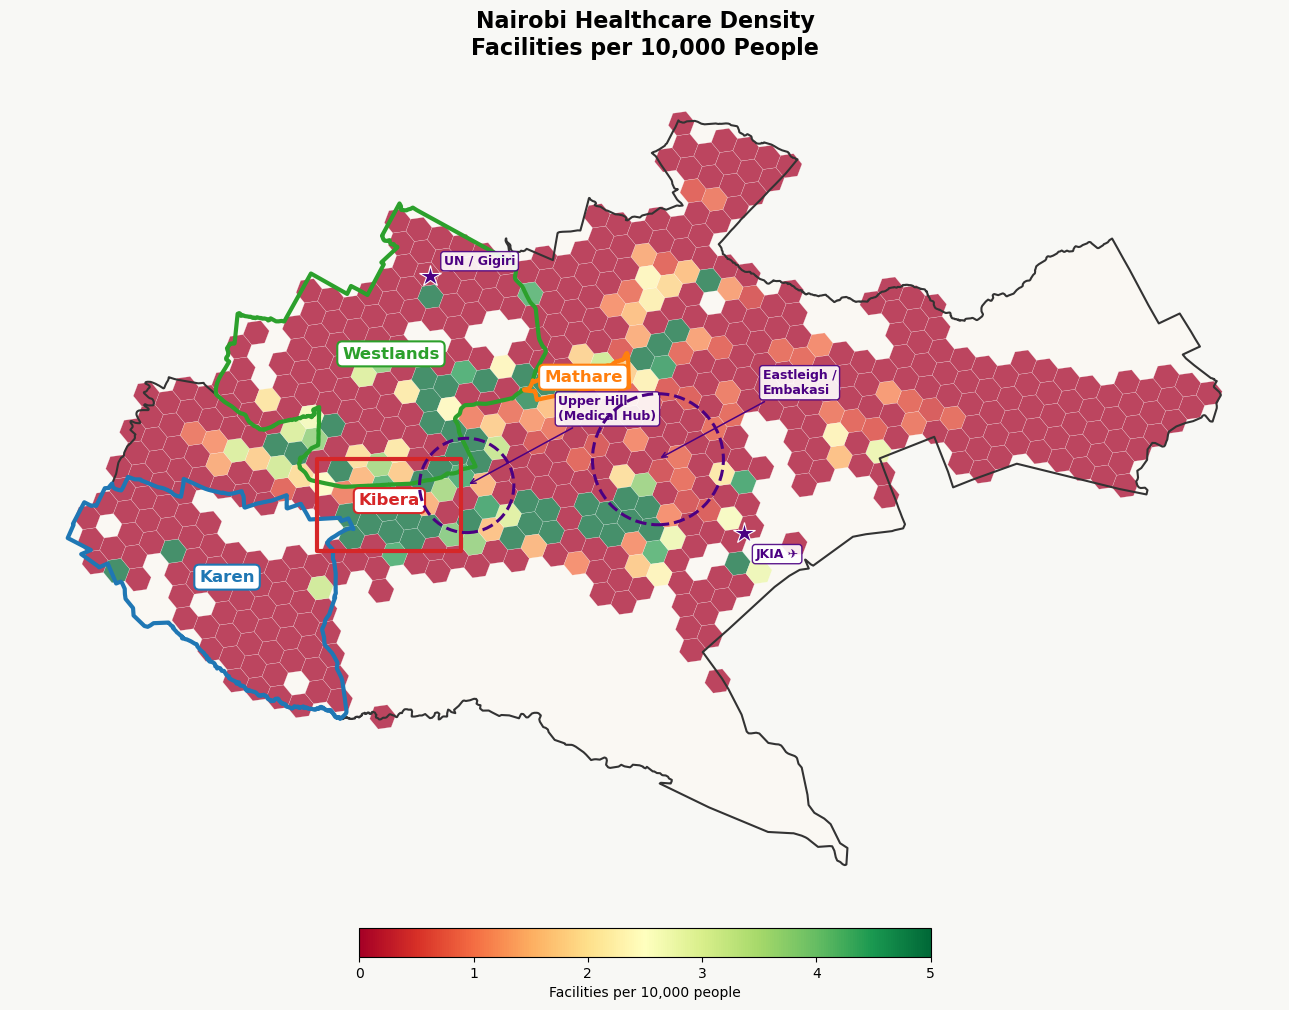

In [52]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(13, 13), facecolor='#f8f8f5')

nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#faf8f3', edgecolor='none')

gdf_hex_plot = gdf_hex[gdf_hex['per_10k'].notna()].copy()
gdf_hex_plot.plot(
    column='per_10k', cmap='RdYlGn',
    ax=ax, alpha=0.72, legend=True,
    legend_kwds={'label': 'Facilities per 10,000 people',
                 'shrink': 0.45, 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor='white', linewidth=0.2,
    vmin=0, vmax=5
)

nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1.5)

for name, gdf in areas.items():
    gdf.to_crs('EPSG:4326').plot(ax=ax, color='none',
                                  edgecolor=area_colors[name], linewidth=3)
    c = gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0]
    ax.annotate(name, xy=(c.x, c.y), fontsize=12, fontweight='bold',
                color=area_colors[name], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=area_colors[name], linewidth=1.5))

# --- Dashed circles for landmark districts ---
landmark_circles = [
    # (lon, lat, radius, label, label_lon, label_lat, ha)
    (36.817, -1.300, 0.018, 'Upper Hill\n(Medical Hub)', 36.852, -1.275, 'left'),
    (36.890, -1.290, 0.025, 'Eastleigh /\nEmbakasi',    36.930, -1.265, 'left'),
]
for lon, lat, r, label, llon, llat, ha in landmark_circles:
    ax.add_patch(Circle((lon, lat), radius=r,
                         edgecolor='#4b0082', facecolor='none',
                         linewidth=2.2, linestyle='--', zorder=5))
    ax.annotate(label, xy=(lon, lat), xytext=(llon, llat),
                fontsize=9, fontweight='bold', color='#4b0082', ha=ha,
                arrowprops=dict(arrowstyle='->', color='#4b0082', lw=1.1),
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#4b0082', linewidth=1, alpha=0.9))

# --- Star markers for point landmarks ---
point_landmarks = {
    'UN / Gigiri': (36.803, -1.220),
    'JKIA ✈':      (36.923, -1.318),
}
offsets = {
    'UN / Gigiri': (10,  8),
    'JKIA ✈':      (8, -18),
}
for label, (lon, lat) in point_landmarks.items():
    ax.plot(lon, lat, marker='*', color='#4b0082', markersize=16,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)
    ax.annotate(label, xy=(lon, lat), xytext=offsets[label],
                textcoords='offset points', fontsize=9, fontweight='bold',
                color='#4b0082',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#4b0082', linewidth=1, alpha=0.9))

ax.set_title('Nairobi Healthcare Density\nFacilities per 10,000 People',
             fontsize=16, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/02_density_per10k.png', dpi=200, bbox_inches='tight')
plt.show()

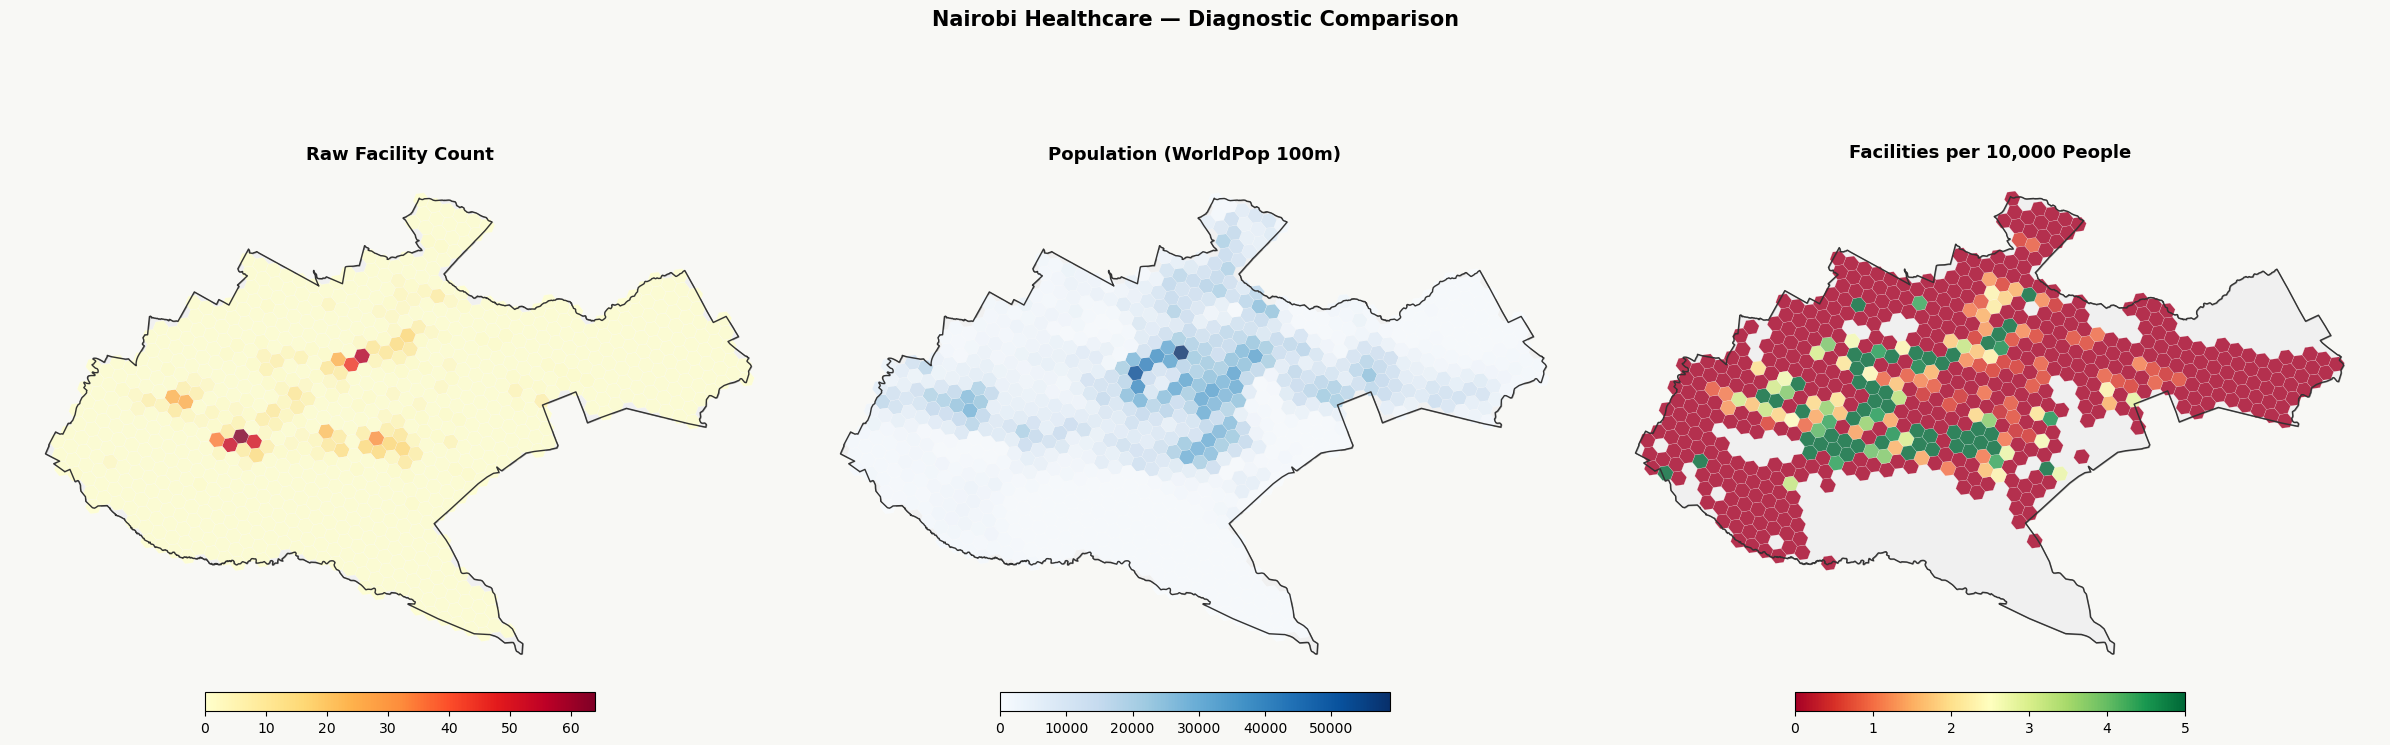

In [50]:
# Diagnostic: raw facility count / population / per_10k side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='#f8f8f5')

panels = [
    ('facility_cnt', 'Raw Facility Count',         'YlOrRd', None, None),
    ('population',   'Population (WorldPop 100m)',  'Blues',  None, None),
    ('per_10k',      'Facilities per 10,000 People','RdYlGn', 0,    5   ),
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, panels):
    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#f0f0f0', edgecolor='#999', linewidth=0.8)

    plot_data = gdf_hex[gdf_hex[col].notna()].copy()
    kwargs = dict(column=col, cmap=cmap, ax=ax, alpha=0.8,
                  legend=True, edgecolor='white', linewidth=0.15,
                  legend_kwds={'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02})
    if vmin is not None:
        kwargs['vmin'] = vmin
        kwargs['vmax'] = vmax
    plot_data.plot(**kwargs)

    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle('Nairobi Healthcare — Diagnostic Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/00_diagnostic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# 检查右侧绿色异常区域（大概在经度 36.88-36.95，纬度 -1.28 to -1.32 之间）
from shapely.geometry import box
suspect_box = box(36.88, -1.32, 36.96, -1.25)
suspect_fac = nairobi_health[nairobi_health.to_crs('EPSG:4326').within(suspect_box)]
print(suspect_fac['fclass'].value_counts())
print(f'Total: {len(suspect_fac)}')

# 看该区域的人口
suspect_hex = gdf_hex[gdf_hex.to_crs('EPSG:4326').geometry.centroid.within(suspect_box)]
print(suspect_hex[['facility_cnt','population','per_10k']].describe())

fclass
clinic      42
pharmacy    29
hospital    23
doctors      1
Name: count, dtype: int64
Total: 95
       facility_cnt    population    per_10k
count     84.000000     84.000000  70.000000
mean       1.071429  14553.402843   0.782408
std        2.793218  10602.945047   1.725026
min        0.000000      2.555110   0.000000
25%        0.000000   4146.917908   0.000000
50%        0.000000  15289.439941   0.000000
75%        1.000000  22734.168945   0.640356
max       16.000000  32801.472656   8.837153


## Step 4 — Walking Network & Multi-source Dijkstra

In [18]:
import os

WALK_SPEED_MS = 5 * 1000 / 3600   # 5 km/h in m/s

if os.path.exists(WALK_GRAPH):
    print('Loading saved walk graph...')
    G_walk = ox.load_graphml(WALK_GRAPH)
else:
    print('Downloading walk network (may take 3–5 min)...')
    G_walk = ox.graph_from_polygon(nairobi_poly, network_type='walk', simplify=True)
    # Add travel time (seconds) to each edge
    for u, v, k, data in G_walk.edges(keys=True, data=True):
        data['travel_time'] = data['length'] / WALK_SPEED_MS
    ox.save_graphml(G_walk, WALK_GRAPH)
    print('Saved to', WALK_GRAPH)

print(f'Nodes: {len(G_walk.nodes):,}   Edges: {len(G_walk.edges):,}')

Saved to ../Data/processed/nairobi_walk.graphml
Nodes: 72,265   Edges: 176,850


In [19]:
def multi_source_walk_time(G, facility_gdf):
    """Return dict {node_id: seconds_to_nearest_facility} via multi-source Dijkstra."""
    fac_wgs = facility_gdf.to_crs('EPSG:4326')
    fac_nodes = list(set(ox.distance.nearest_nodes(
        G, X=fac_wgs.geometry.x.values, Y=fac_wgs.geometry.y.values
    )))
    print(f'  Facility nodes: {len(fac_nodes)}')

    # Super-source trick: add a virtual node connected to all facility nodes at cost 0
    G2 = G.copy()
    SUPER = '__super__'
    G2.add_node(SUPER)
    for n in fac_nodes:
        G2.add_edge(SUPER, n, travel_time=0)

    times = nx.single_source_dijkstra_path_length(G2, source=SUPER, weight='travel_time')
    times.pop(SUPER, None)
    return times

# --- To nearest hospital ---
hospitals = nairobi_health[nairobi_health['fclass'] == 'hospital']
print(f'Hospitals: {len(hospitals)}')
times_hospital = multi_source_walk_time(G_walk, hospitals)

# --- To nearest any facility ---
print(f'All facilities: {len(nairobi_health)}')
times_any = multi_source_walk_time(G_walk, nairobi_health)

Hospitals: 146
  Facility nodes: 136
All facilities: 980
  Facility nodes: 729


In [53]:
# Map hexagon centroids → nearest walk-network node → travel time
hex_wgs = gdf_hex.to_crs('EPSG:4326')
centroids = hex_wgs.geometry.centroid

nearest_nodes = ox.distance.nearest_nodes(
    G_walk, X=centroids.x.values, Y=centroids.y.values
)

gdf_hex['walk_min_hospital'] = [
    times_hospital.get(n, np.nan) / 60 for n in nearest_nodes
]
gdf_hex['walk_min_any'] = [
    times_any.get(n, np.nan) / 60 for n in nearest_nodes
]

print('Walk time to hospital (minutes):')
print(gdf_hex['walk_min_hospital'].describe())

Walk time to hospital (minutes):
count    865.000000
mean      58.302961
std       50.467652
min        0.227326
25%       22.105062
50%       42.619305
75%       82.807353
max      296.427310
Name: walk_min_hospital, dtype: float64


## Step 5 — Walk-Time Accessibility Maps

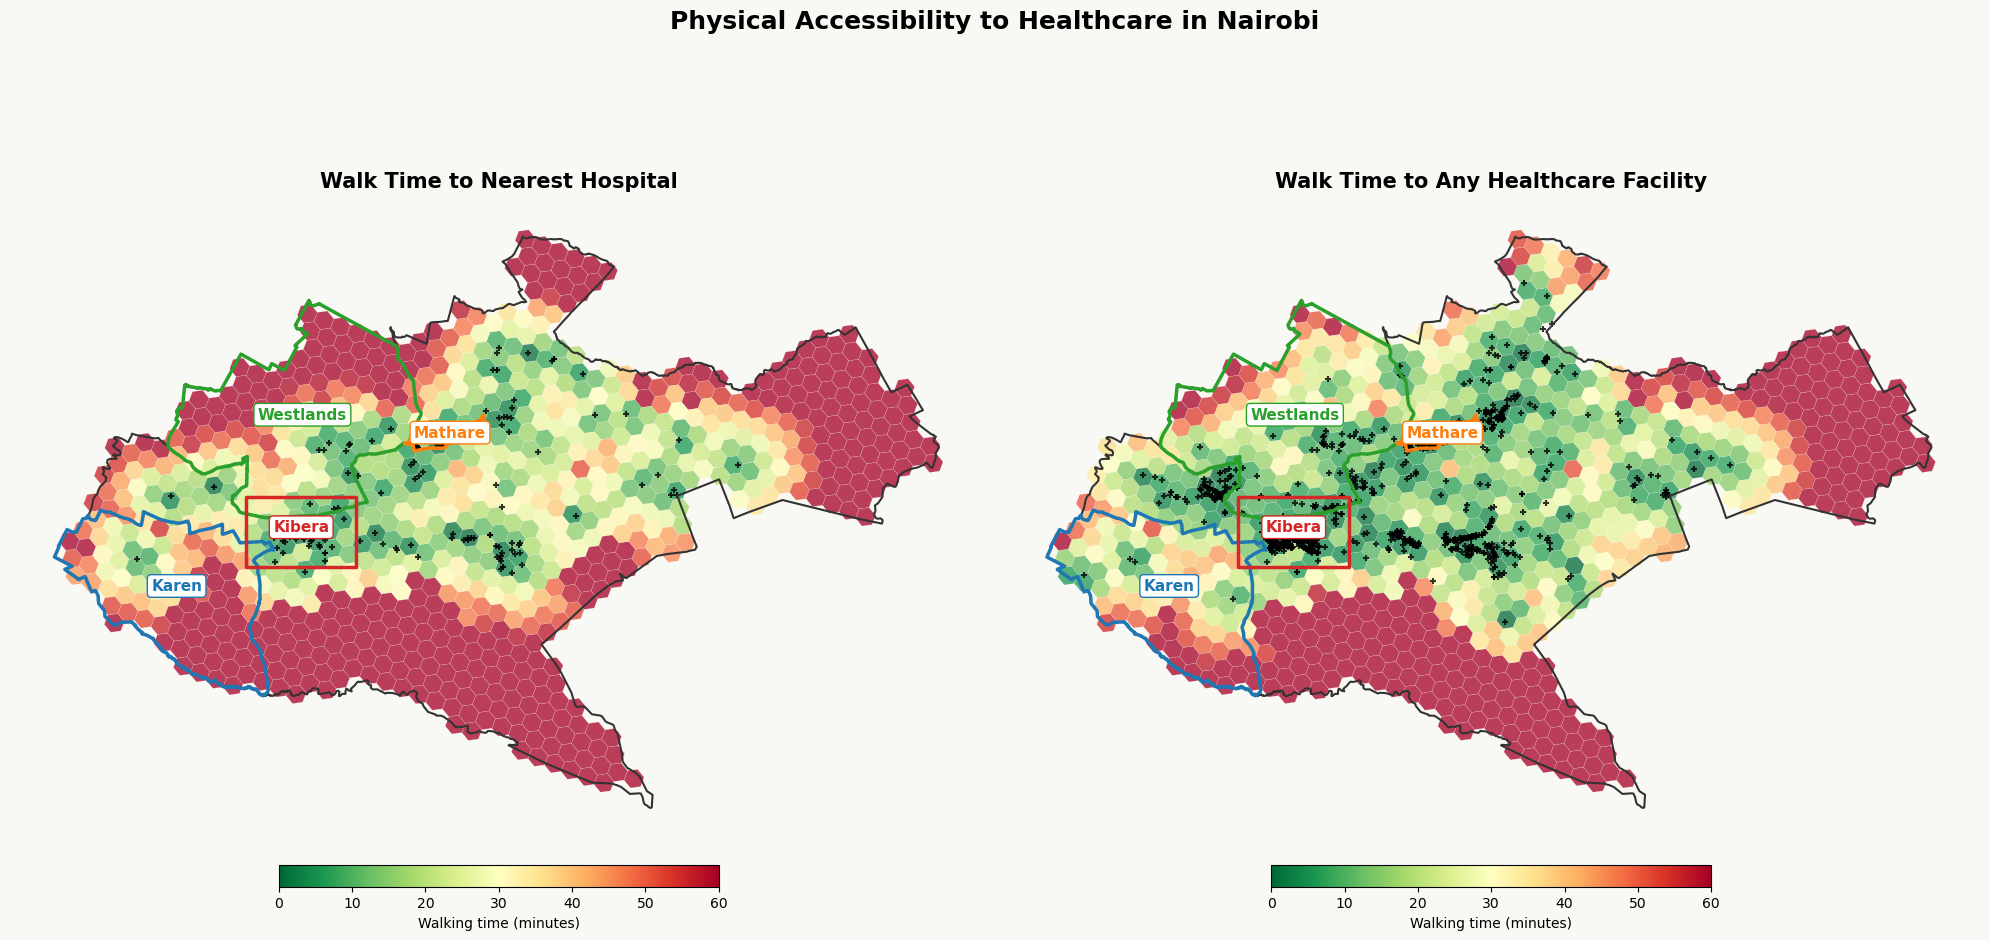

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#f8f8f5')

panels = [
    ('walk_min_hospital', 'Walk Time to Nearest Hospital', hospitals),
    ('walk_min_any',      'Walk Time to Any Healthcare Facility', nairobi_health),
]

for ax, (col, title, pts) in zip(axes, panels):
    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='#faf8f3', edgecolor='none')

    plot_data = gdf_hex[gdf_hex[col].notna()].copy()
    plot_data[col] = plot_data[col].clip(upper=90)

    plot_data.plot(
        column=col, cmap='RdYlGn_r',
        vmin=0, vmax=60,
        ax=ax, alpha=0.75, legend=True,
        legend_kwds={'label': 'Walking time (minutes)',
                     'shrink': 0.45, 'orientation': 'horizontal', 'pad': 0.03},
        edgecolor='white', linewidth=0.15
    )

    pts.to_crs('EPSG:4326').plot(ax=ax, color='black', markersize=20,
                                  marker='+', linewidth=1.5, alpha=0.8)

    nairobi.to_crs('EPSG:4326').plot(ax=ax, color='none', edgecolor='#333', linewidth=1.5)

    for name, gdf in areas.items():
        gdf.to_crs('EPSG:4326').plot(ax=ax, color='none',
                                      edgecolor=area_colors[name], linewidth=2.5)
        c = gdf.to_crs('EPSG:4326').geometry.centroid.iloc[0]
        ax.annotate(name, xy=(c.x, c.y), fontsize=11, fontweight='bold',
                    color=area_colors[name], ha='center',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor=area_colors[name]))

    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Physical Accessibility to Healthcare in Nairobi',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/03_walk_time.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 6 — Per-Area Summary Statistics

In [55]:
results = []
for name, gdf in areas.items():
    area_poly = gdf.to_crs('EPSG:4326').geometry.values[0]
    area_km2  = gdf.to_crs('EPSG:32737').geometry.area.iloc[0] / 1e6

    # Facilities inside this area
    fac_in = nairobi_health[nairobi_health.to_crs('EPSG:4326').within(area_poly)]
    hosp_in = fac_in[fac_in['fclass'] == 'hospital']

    # Population from WorldPop via zonal stats
    pop_stat = zonal_stats(gdf.to_crs('EPSG:4326'), POP_RASTER, stats=['sum'])
    pop = pop_stat[0]['sum'] or 0

    # Hexagons within this area (centroid-based)
    hex_in = gdf_hex[gdf_hex.to_crs('EPSG:4326').geometry.centroid.within(area_poly)]
    hex_valid = hex_in.dropna(subset=['walk_min_hospital'])

    if len(hex_valid) > 0 and hex_valid['population'].sum() > 0:
        w_time = np.average(hex_valid['walk_min_hospital'],
                            weights=hex_valid['population'])
        pop_total = hex_valid['population'].sum()
        pct15 = hex_valid[hex_valid['walk_min_hospital'] <= 15]['population'].sum() / pop_total * 100
        pct30 = hex_valid[hex_valid['walk_min_hospital'] <= 30]['population'].sum() / pop_total * 100
        pct60 = hex_valid[hex_valid['walk_min_hospital'] <= 60]['population'].sum() / pop_total * 100
    else:
        w_time = pct15 = pct30 = pct60 = np.nan

    results.append({
        'Area':                    name,
        'Area km²':                round(area_km2, 1),
        'Population (WorldPop)':   int(pop),
        'All facilities':          len(fac_in),
        'Hospitals':               len(hosp_in),
        'Facilities/10k people':   round(len(fac_in) / pop * 10000, 2) if pop > 0 else np.nan,
        'Avg walk to hospital (min)': round(w_time, 1),
        '% pop <15 min':           round(pct15, 1),
        '% pop <30 min':           round(pct30, 1),
        '% pop <60 min':           round(pct60, 1),
    })

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/tables/area_summary.csv', index=False)
print(df_results.to_string(index=False))

     Area  Area km²  Population (WorldPop)  All facilities  Hospitals  Facilities/10k people  Avg walk to hospital (min)  % pop <15 min  % pop <30 min  % pop <60 min
    Karen      71.3                 101925               4          1                   0.39                        56.3            5.3           16.4           54.6
Westlands      97.5                 324665              75         12                   2.31                        38.9           23.5           43.7           78.9
   Kibera      23.7                 222286             281         38                  12.64                        11.5           73.5           97.3          100.0
  Mathare       3.0                 193786             129         18                   6.66                         7.2          100.0          100.0          100.0


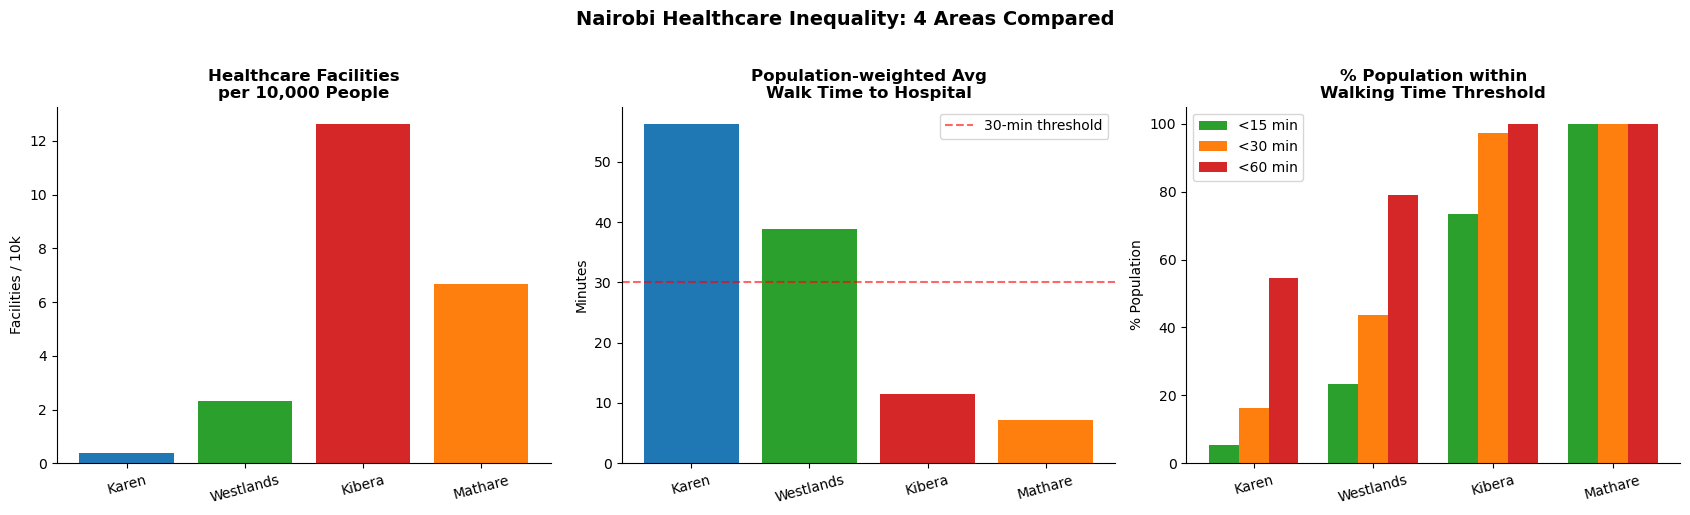

In [56]:
# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_list = [area_colors[n] for n in df_results['Area']]

axes[0].bar(df_results['Area'], df_results['Facilities/10k people'], color=colors_list)
axes[0].set_title('Healthcare Facilities\nper 10,000 People', fontweight='bold')
axes[0].set_ylabel('Facilities / 10k')

axes[1].bar(df_results['Area'], df_results['Avg walk to hospital (min)'], color=colors_list)
axes[1].axhline(30, color='red', linestyle='--', alpha=0.6, label='30-min threshold')
axes[1].set_title('Population-weighted Avg\nWalk Time to Hospital', fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].legend()

x = np.arange(len(df_results))
w = 0.25
axes[2].bar(x - w, df_results['% pop <15 min'],  w, label='<15 min', color='#2ca02c')
axes[2].bar(x,     df_results['% pop <30 min'],  w, label='<30 min', color='#ff7f0e')
axes[2].bar(x + w, df_results['% pop <60 min'],  w, label='<60 min', color='#d62728')
axes[2].set_xticks(x); axes[2].set_xticklabels(df_results['Area'])
axes[2].set_title('% Population within\nWalking Time Threshold', fontweight='bold')
axes[2].set_ylabel('% Population')
axes[2].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Nairobi Healthcare Inequality: 4 Areas Compared',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/04_area_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Limitations

- OSM may underrepresent informal healthcare providers in Kibera/Mathare; actual facility counts in informal settlements are likely higher than recorded
- WorldPop likely underestimates population in dense informal settlements (high-density tin-roof structures)
- Walk-time assumes 5 km/h on all mapped paths; narrow informal settlement alleyways may be slower in practice
- Unmapped footpaths in OSM will bias Kibera/Mathare walk times upward
- The Eastleigh/Embakasi corridor shows elevated facility-per-capita values, likely because WorldPop (a residential population model) underestimates daytime workers near JKIA and commercial zones; these readings should not be interpreted as genuine high accessibility for residents
- Analysis is limited to walking accessibility; car-dependent areas such as Karen and Westlands have better effective access to Upper Hill's medical hub than walk-time alone suggests